In [1]:
import pandas as pd
import numpy as np
from skimage.metrics import structural_similarity as ssim
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("mds_all_integrated_harmony.csv")

color_map = {
    "progenitor": "#6abd12",
    "MBO": "#bce590",

    "VZ_neuroblast_1": "#facc15",
    "VZ_neuroblast_2": "#fde047",
    "VZ_neuroblast_3": "#fef08a",

    "NTZ_neuroblast_1": "#7d5207",
    "NTZ_neuroblast_2": "#b39054",
    "NTZ_neuroblast_3": "#ecd09f",

    "GCP": "#7f1d1d",
    "GC_diff_1": "#f76161",
    "GC_diff_2": "#ff9f9f",
    "GC_defined": "#ffd5d5",

    "GCP/UBCP": "#f27500",
    "GC/UBC_diff": "#fb9f4a",
    "UBC_diff": "#f7b272",
    "UBC_defined": "#fdc999",

    "Purkinje_diff": "#0a229b",
    "Purkinje_defined": "#90a2f2",
    "Purkinje_maturing": "#cbd4f9",

    "interneuron_diff": "#069372",
    "interneuron_defined": "#7cd9c3",
    "GABA_DN_defined": "#c2ece2",

    "glut_DN_defined": "#ae3970",
    "isth_N_diff": "#fdb8e9",
    "isth_N_defined": "#ffe1f7",

    "glioblast": "#550584",
    "oligo_progenitor": "#8c2ebf",
    "oligodendrocyte": "#c38ce3",
    "astrocyte": "#d7c8f0",
    
    "meningeal": "#1a1a1a",
    "parabrachial": "#4d4d4d"
}

In [4]:
def make_density_map(
    df_sub,
    x_col="MDS_1",
    y_col="MDS_2",
    grid_size=50,
    coord_range=(-1, 1),
    bw_method=None,
    min_cells=3
):

    use = df_sub[
        df_sub[x_col].between(coord_range[0], coord_range[1])
        & df_sub[y_col].between(coord_range[0], coord_range[1])
    ].dropna(subset=[x_col, y_col])

    if len(use) < min_cells:
        return np.full(
            (grid_size, grid_size),
            np.nan
        )

    x_grid = np.linspace(
        coord_range[0],
        coord_range[1],
        grid_size
    )

    y_grid = np.linspace(
        coord_range[0],
        coord_range[1],
        grid_size
    )

    xx, yy = np.meshgrid(x_grid, y_grid)

    coordinates = np.vstack([
        use[x_col].to_numpy(),
        use[y_col].to_numpy()
    ])

    try:
        kde = gaussian_kde(
            coordinates,
            bw_method=bw_method
        )

        grid_positions = np.vstack([
            xx.ravel(),
            yy.ravel()
        ])

        density = kde(
            grid_positions
        ).reshape(grid_size, grid_size)

    except (np.linalg.LinAlgError, ValueError):
        return np.full(
            (grid_size, grid_size),
            np.nan
        )

    density_sum = density.sum()

    if density_sum > 0:
        density = density / density_sum

    return density

In [5]:
def make_annotation_density_maps(
    df_stage,
    annotation_col="annotation",
    x_col="MDS_1",
    y_col="MDS_2",
    annotations=None,
    grid_size=50,
    coord_range=(-1, 1),
    bw_method=None,
    min_cells=3
):
    if annotations is None:
        annotations = sorted(
            df_stage[annotation_col].dropna().unique()
        )

    density_maps = {}
    cell_counts = {}

    for anno in annotations:
        df_sub = df_stage[
            df_stage[annotation_col] == anno
        ]

        cell_counts[anno] = len(df_sub)

        if len(df_sub) == 0:
            density_maps[anno] = None
            continue

        density_maps[anno] = make_density_map(
            df_sub=df_sub,
            x_col=x_col,
            y_col=y_col,
            grid_size=grid_size,
            coord_range=coord_range,
            bw_method=bw_method,
            min_cells=min_cells
        )

    return density_maps, cell_counts

In [6]:
def calculate_s_color_weighted(
    maps_a,
    maps_b,
    counts_a,
    counts_b,
    annotations=None
):
    if annotations is None:
        annotations = sorted(
            set(maps_a.keys()) | set(maps_b.keys())
        )

    total_a = sum(counts_a.values())
    total_b = sum(counts_b.values())

    scores = {}
    weights = {}

    for anno in annotations:
        map_a = maps_a.get(anno)
        map_b = maps_b.get(anno)

        count_a = counts_a.get(anno, 0)
        count_b = counts_b.get(anno, 0)

        prop_a = count_a / total_a if total_a > 0 else 0
        prop_b = count_b / total_b if total_b > 0 else 0

        weights[anno] = (prop_a + prop_b) / 2

        if map_a is None or map_b is None:
            scores[anno] = 0.0
            continue

        if np.isnan(map_a).any() or np.isnan(map_b).any():
            scores[anno] = 0.0
            continue

        data_range = max(map_a.max(), map_b.max()) - min(
            map_a.min(), map_b.min()
        )

        if data_range == 0:
            scores[anno] = 1.0
        else:
            scores[anno] = float(
                ssim(
                    map_a,
                    map_b,
                    data_range=data_range
                )
            )

    score_array = np.array([
        scores[a] for a in annotations
    ])

    weight_array = np.array([
        weights[a] for a in annotations
    ])

    if weight_array.sum() > 0:
        weight_array = weight_array / weight_array.sum()

    s_color = np.sum(score_array * weight_array)

    return s_color, scores, weights

In [7]:
stage_pairs = [
    ("E10.5", "E11.5"),
    ("E11.5", "E12.5"),
    ("E12.5", "E13.5"),
    ("E13.5", "E14.5"),
    ("E14.5", "E15.5"),
    ("E15.5", "E17.5"),
    ("E17.5", "P0"),
    ("P0", "P4"),
    ("P4", "P7"),
    ("P7", "P14"),
    ("P14", "adult")
]

In [27]:
results = []

for stage_a, stage_b in stage_pairs:

    df_a = df[df["stage"] == stage_a]
    df_b = df[df["stage"] == stage_b]

    annotation_union = sorted(
        set(df_a["annotation"].dropna())
        | set(df_b["annotation"].dropna())
    )

    maps_a, counts_a = make_annotation_density_maps(
        df_a,
        annotations=annotation_union,
        annotation_col="annotation",
        x_col="MDS_1",
        y_col="MDS_2",
        grid_size=50,
        coord_range=(-1, 1),
        min_cells=3
    )

    maps_b, counts_b = make_annotation_density_maps(
        df_b,
        annotations=annotation_union,
        annotation_col="annotation",
        x_col="MDS_1",
        y_col="MDS_2",
        grid_size=50,
        coord_range=(-1, 1),
        min_cells=3
    )

    s_color, anno_scores, anno_weights = (
        calculate_s_color_weighted(
            maps_a=maps_a,
            maps_b=maps_b,
            counts_a=counts_a,
            counts_b=counts_b,
            annotations=annotation_union
        )
    )

    results.append({
        "stage_a": stage_a,
        "stage_b": stage_b,
        "S_color": s_color,
        "annotation_scores": anno_scores,
        "annotation_weights": anno_weights,
        "counts_a": counts_a,
        "counts_b": counts_b
    })

In [28]:
s_color_df = pd.DataFrame([
    {
        "stage_a": result["stage_a"],
        "stage_b": result["stage_b"],
        "S_color": result["S_color"]
    }
    for result in results
])

s_color_df

,stage_a,stage_b,S_color
0,E10.5,E11.5,0.573792
1,E11.5,E12.5,0.647845
2,E12.5,E13.5,0.792092
3,E13.5,E14.5,0.819811
4,E14.5,E15.5,0.871281
5,E15.5,E17.5,0.827458
6,E17.5,P0,0.892578
7,P0,P4,0.791780
8,P4,P7,0.885224
9,P7,P14,0.580657


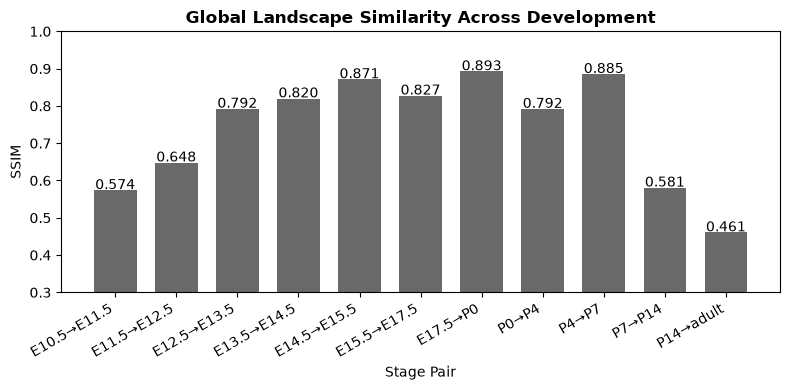

In [30]:
s_color_df["pair"] = (
    s_color_df["stage_a"] + "→" + s_color_df["stage_b"]
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    s_color_df["pair"],
    s_color_df["S_color"],
    width=0.7,
    color="dimgray"
)

ax.set_ylim(0.3, 1)
ax.set_ylabel("SSIM")
ax.set_xlabel("Stage Pair")
ax.set_title("Global Landscape Similarity Across Development",
            fontweight='bold')

for i, v in enumerate(s_color_df["S_color"]):
    ax.text(i, v + 0.003, f"{v:.3f}",
            ha="center", fontsize=10)
    
plt.xticks(rotation=30, ha="right")


plt.tight_layout()
plt.savefig("SSIM_all.png",bbox_inches="tight")
plt.show()

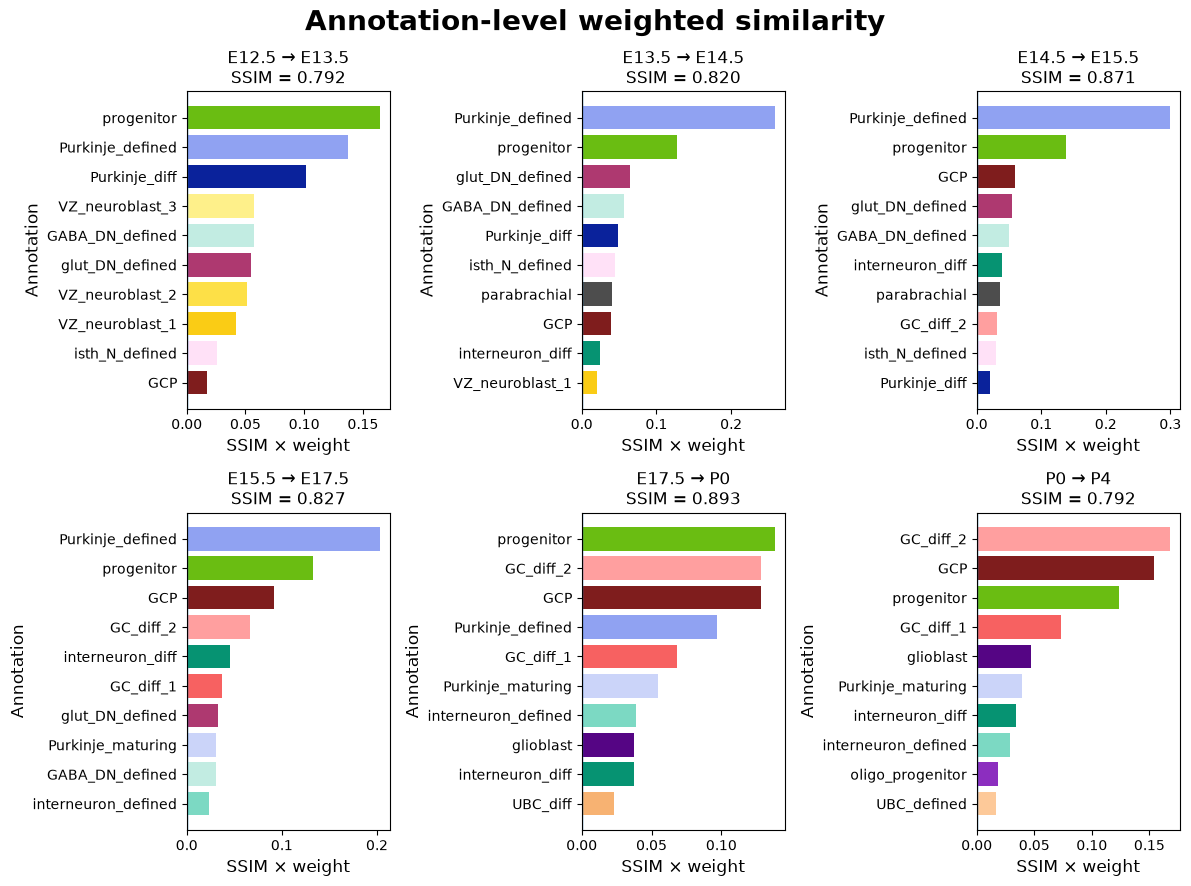

In [32]:
# which cell type contribute landscape similarity


fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 9)
)

axes = axes.ravel()
top_n = 10

for pair_idx in range(2, 8):

    result = results[pair_idx]

    annotation_detail = pd.DataFrame([
        {
            "annotation": anno,
            "SSIM": result["annotation_scores"][anno],
            "weight": result["annotation_weights"][anno],
            "count_a": result["counts_a"].get(anno, 0),
            "count_b": result["counts_b"].get(anno, 0)
        }
        for anno in result["annotation_scores"]
    ])

    annotation_detail["weighted_score"] = (
        annotation_detail["SSIM"]
        * annotation_detail["weight"]
    )

    plot_df = (
        annotation_detail
        .nlargest(top_n, "weighted_score")
        .sort_values("weighted_score")
    )

    ax = axes[pair_idx - 2] 


    bar_colors = [
        color_map.get(annotation, "#bdbdbd")
        for annotation in plot_df["annotation"]
    ]

    ax.barh(
        plot_df["annotation"],
        plot_df["weighted_score"],
        color=bar_colors
    )
    

    ax.axvline(
        0,
        linewidth=1
    )

    ax.set_title(
        f'{result["stage_a"]} → {result["stage_b"]}\n'
        f'SSIM = {result["S_color"]:.3f}'
    )

    ax.set_xlabel("SSIM × weight", fontsize = 12)
    ax.set_ylabel("Annotation", fontsize =  12)


    fig.suptitle(
    "Annotation-level weighted similarity",
    fontsize=20,
    fontweight="bold",
    y=0.98)

plt.tight_layout()
plt.savefig("Top10_similarity.png",bbox_inches="tight")
plt.show()

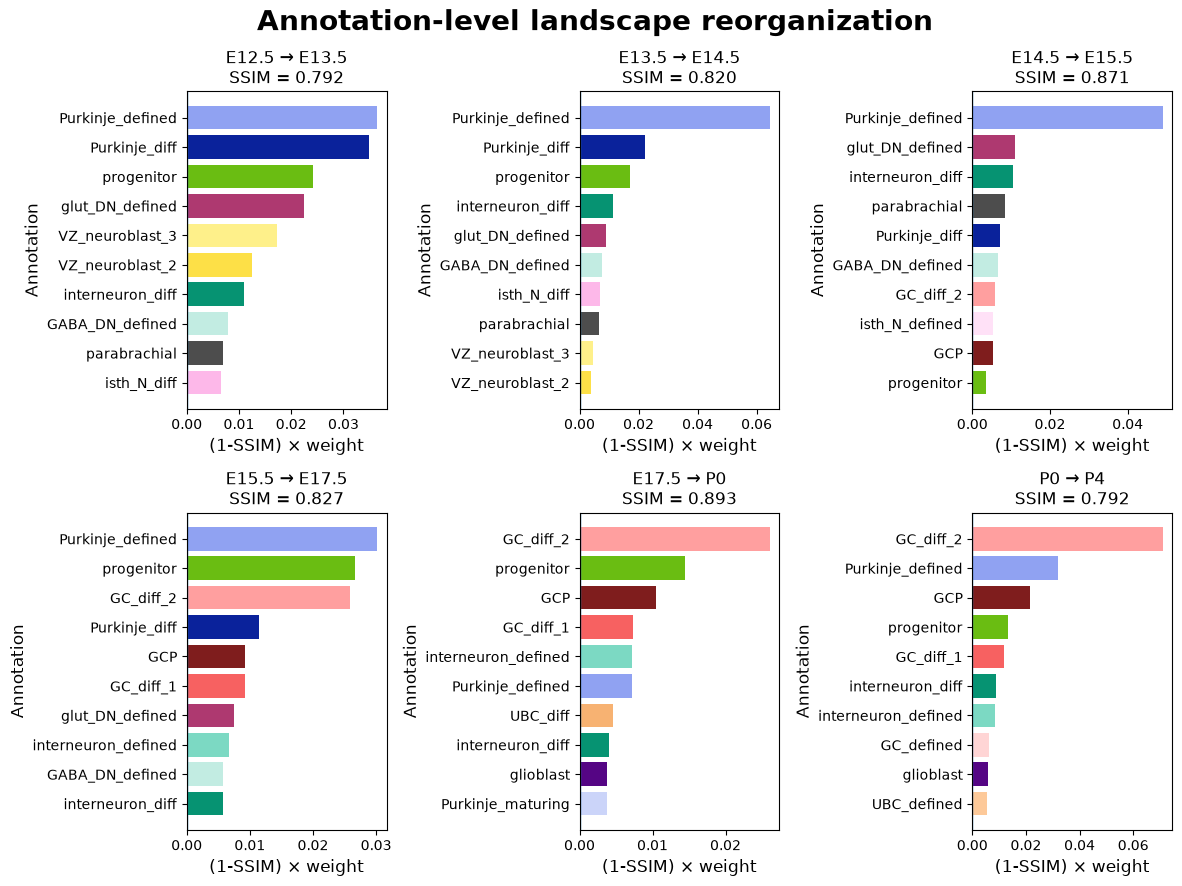

In [33]:
# which cell type contribute landscape reorganization

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 9)
)

axes = axes.ravel()
top_n = 10

for pair_idx in range(2,8):

    result = results[pair_idx]

    annotation_detail = pd.DataFrame([
        {
            "annotation": anno,
            "SSIM": result["annotation_scores"][anno],
            "weight": result["annotation_weights"][anno],
            "count_a": result["counts_a"].get(anno, 0),
            "count_b": result["counts_b"].get(anno, 0)
        }
        for anno in result["annotation_scores"]
    ])

    annotation_detail["weighted_change"] = (
        (1 - annotation_detail["SSIM"])
        * annotation_detail["weight"]
    )

    plot_df = (
        annotation_detail
        .nlargest(top_n, "weighted_change")
        .sort_values("weighted_change")
    )

    ax = axes[pair_idx - 2]

    bar_colors = [
        color_map.get(annotation, "#bdbdbd")
        for annotation in plot_df["annotation"]
    ]


    ax.barh(
        plot_df["annotation"],
        plot_df["weighted_change"],
        color=bar_colors
    )

    ax.axvline(
        0,
        linewidth=1
    )

    ax.set_title(
        f'{result["stage_a"]} → {result["stage_b"]}\n'
        f'SSIM = {result["S_color"]:.3f}'
    )

    ax.set_xlabel("(1-SSIM) × weight", fontsize = 12)
    ax.set_ylabel("Annotation", fontsize = 12)

    fig.suptitle(
    "Annotation-level landscape reorganization",
    fontsize=20,
    fontweight="bold",
    y=0.98)

plt.tight_layout()
plt.savefig("Top10_reorganization.png",bbox_inches="tight")
plt.show()

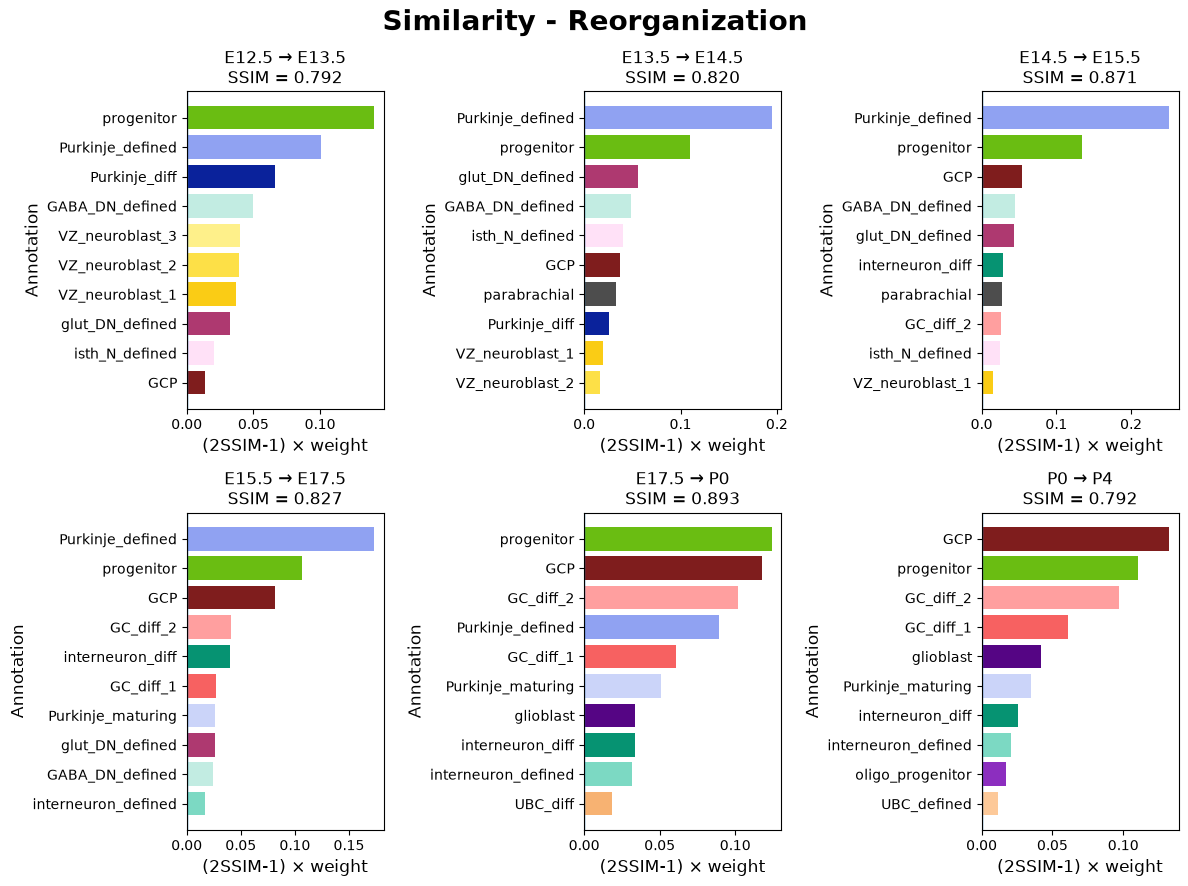

In [34]:
# similarity -  reorganization

fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 9)
)

axes = axes.ravel()
top_n = 10

for pair_idx in range(2,8):

    result = results[pair_idx]

    annotation_detail = pd.DataFrame([
        {
            "annotation": anno,
            "SSIM": result["annotation_scores"][anno],
            "weight": result["annotation_weights"][anno],
            "count_a": result["counts_a"].get(anno, 0),
            "count_b": result["counts_b"].get(anno, 0)
        }
        for anno in result["annotation_scores"]
    ])

    annotation_detail["weighted_change"] = (
        (2*annotation_detail["SSIM"] - 1)
        * annotation_detail["weight"]
    )

    plot_df = (
        annotation_detail
        .nlargest(top_n, "weighted_change")
        .sort_values("weighted_change")
    )

    ax = axes[pair_idx - 2]

    bar_colors = [
        color_map.get(annotation, "#bdbdbd")
        for annotation in plot_df["annotation"]
    ]


    ax.barh(
        plot_df["annotation"],
        plot_df["weighted_change"],
        color=bar_colors
    )

    ax.axvline(
        0,
        linewidth=1
    )

    ax.set_title(
        f'{result["stage_a"]} → {result["stage_b"]}\n'
        f'SSIM = {result["S_color"]:.3f}'
    )

    ax.set_xlabel("(2SSIM-1) × weight", fontsize = 12)
    ax.set_ylabel("Annotation", fontsize = 12)

    fig.suptitle(
    "Similarity - Reorganization",
    fontsize=20,
    fontweight="bold",
    y=0.98)

plt.tight_layout()
plt.savefig("similarity-reorganization.png",bbox_inches="tight")
plt.show()

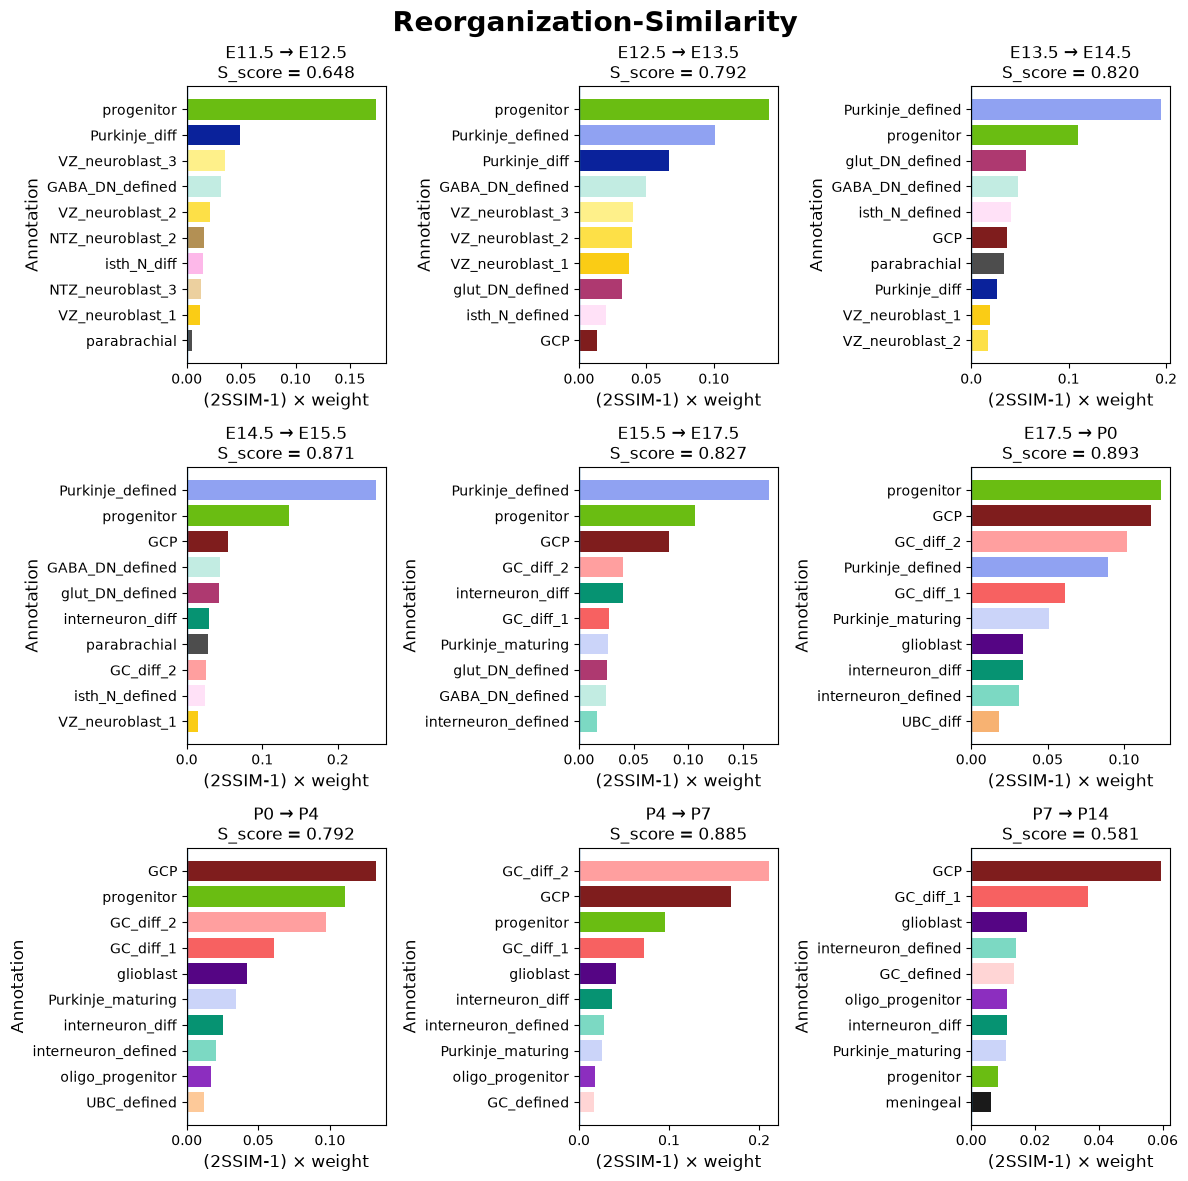

In [19]:
# similarity -  reorganization

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 12)
)

axes = axes.ravel()
top_n = 10

for pair_idx in range(1,10):

    result = results[pair_idx]

    annotation_detail = pd.DataFrame([
        {
            "annotation": anno,
            "SSIM": result["annotation_scores"][anno],
            "weight": result["annotation_weights"][anno],
            "count_a": result["counts_a"].get(anno, 0),
            "count_b": result["counts_b"].get(anno, 0)
        }
        for anno in result["annotation_scores"]
    ])

    annotation_detail["weighted_change"] = (
        (2*annotation_detail["SSIM"]-1)
        * annotation_detail["weight"]
    )

    plot_df = (
        annotation_detail
        .nlargest(top_n, "weighted_change")
        .sort_values("weighted_change")
    )

    ax = axes[pair_idx - 1]

    bar_colors = [
        color_map.get(annotation, "#bdbdbd")
        for annotation in plot_df["annotation"]
    ]


    ax.barh(
        plot_df["annotation"],
        plot_df["weighted_change"],
        color=bar_colors
    )

    ax.axvline(
        0,
        linewidth=1
    )

    ax.set_title(
        f'{result["stage_a"]} → {result["stage_b"]}\n'
        f'S_score = {result["S_color"]:.3f}'
    )

    ax.set_xlabel("(2SSIM-1) × weight", fontsize = 12)
    ax.set_ylabel("Annotation", fontsize = 12)

    fig.suptitle(
    "Reorganization-Similarity",
    fontsize=20,
    fontweight="bold",
    y=0.98)

plt.tight_layout()
plt.savefig("similarity-reorganization_3X3.png",bbox_inches="tight")
plt.show()

In [8]:
# for robustness supplementary

grid_sizes = [20, 30, 50, 100]
min_cells_list = [3, 10, 50]

results = []

for grid_size in grid_sizes:
    for min_cells in min_cells_list:

        for stage_a, stage_b in stage_pairs:

            df_a = df[df["stage"] == stage_a]
            df_b = df[df["stage"] == stage_b]

            annotation_union = sorted(
                set(df_a["annotation"].dropna())
                | set(df_b["annotation"].dropna())
            )

            maps_a, counts_a = make_annotation_density_maps(
                df_a,
                annotations=annotation_union,
                annotation_col="annotation",
                x_col="MDS_1",
                y_col="MDS_2",
                grid_size=grid_size,
                coord_range=(-1, 1),
                min_cells=min_cells
            )

            maps_b, counts_b = make_annotation_density_maps(
                df_b,
                annotations=annotation_union,
                annotation_col="annotation",
                x_col="MDS_1",
                y_col="MDS_2",
                grid_size=grid_size,
                coord_range=(-1, 1),
                min_cells=min_cells
            )

            s_color, anno_scores, anno_weights = (
                calculate_s_color_weighted(
                    maps_a=maps_a,
                    maps_b=maps_b,
                    counts_a=counts_a,
                    counts_b=counts_b,
                    annotations=annotation_union
                )
            )

            results.append({
                "grid_size": grid_size,
                "min_cells": min_cells,
                "stage_a": stage_a,
                "stage_b": stage_b,
                "S_color": s_color,
                "annotation_scores": anno_scores,
                "annotation_weights": anno_weights,
                "counts_a": counts_a,
                "counts_b": counts_b
            })results_df = pd.DataFrame(results)


In [9]:
results_df = pd.DataFrame(results)

summary = results_df[
    ["grid_size", "min_cells", "stage_a", "stage_b", "S_color"]
].copy()

summary

,grid_size,min_cells,stage_a,stage_b,S_color
0,20,3,E10.5,E11.5,0.311668
1,20,3,E11.5,E12.5,0.388910
2,20,3,E12.5,E13.5,0.561265
3,20,3,E13.5,E14.5,0.635369
4,20,3,E14.5,E15.5,0.734749
...,...,...,...,...,...
127,100,50,E17.5,P0,0.903397
128,100,50,P0,P4,0.766639
129,100,50,P4,P7,0.875279
130,100,50,P7,P14,0.466553


In [10]:
summary["stage_pair"] = (
    summary["stage_a"].astype(str)
    + "–"
    + summary["stage_b"].astype(str)
)

summary["parameter"] = (
    "grid=" + summary["grid_size"].astype(str)
    + ", min=" + summary["min_cells"].astype(str)
)

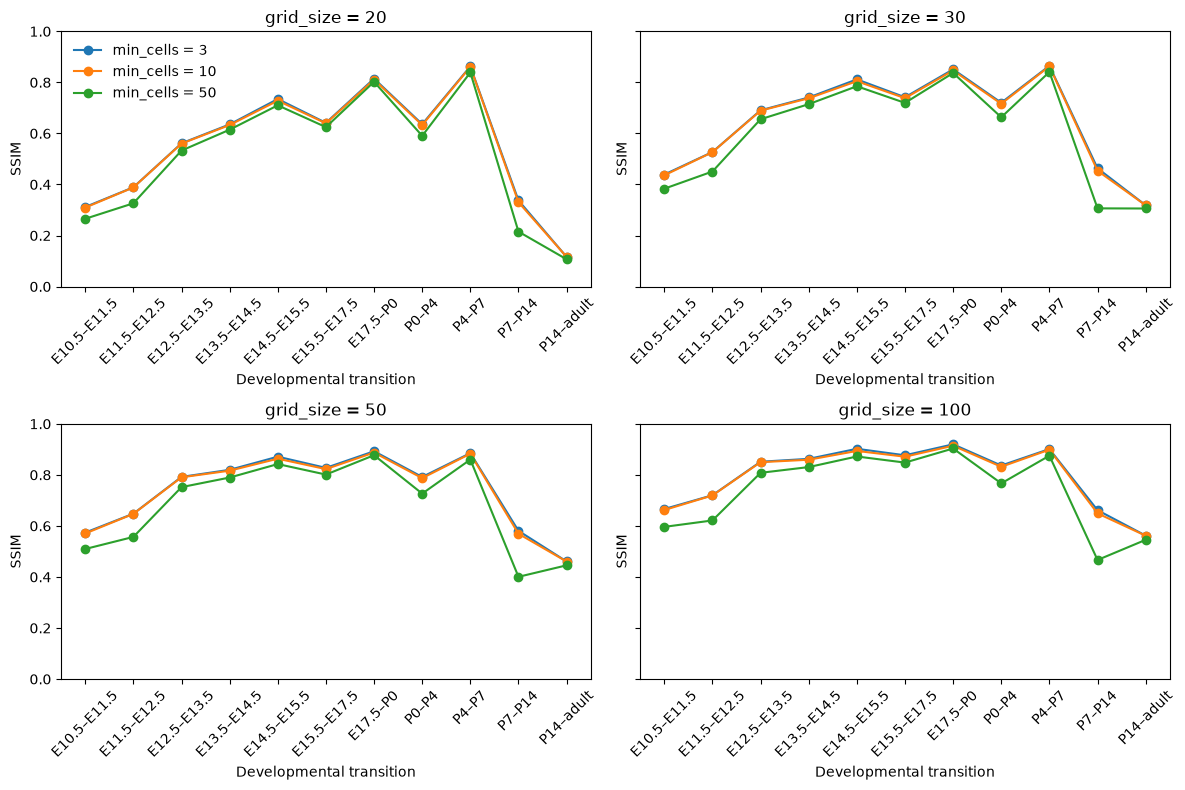

In [18]:
import matplotlib.pyplot as plt

grid_sizes = [20, 30, 50, 100]
min_cells_list = [3, 10, 50]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

axes = axes.flatten()

for ax, grid_size in zip(axes, grid_sizes):

    for min_cells in min_cells_list:

        tmp = summary[
            (summary["grid_size"] == grid_size) &
            (summary["min_cells"] == min_cells)
        ].copy()

        ax.plot(
            tmp["stage_pair"],
            tmp["S_color"],
            marker="o",
            label=f"min_cells = {min_cells}"
        )

    ax.set_title(f"grid_size = {grid_size}")
    ax.set_xlabel("Developmental transition")
    ax.set_ylabel("SSIM")
    ax.set_ylim(0, 1.0)

    ax.tick_params(axis="x", rotation=45)

axes[0].legend(frameon=False)

plt.tight_layout()
plt.savefig("SSIM_robustness.png",bbox_inches="tight")
plt.show()